# FAKE NEWS PREDICTION BY TENSOR FLOW

# IMPORT LIBRARIES

In [2]:
!pip install tensorflow

  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.34.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached grpcio-1.80.0-cp313-cp313-win_amd64.whl.metadata (3.9 kB)
  Using cached keras-3.14.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached ml_dtypes-0.5.4-cp313-cp313-win_amd64.whl.metadata (9.2 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached opt

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.45.1 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.


In [3]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt

# SKLEARN MODEL
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix

# TENSORFLOW /KERAS TOOLS
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,LSTM,Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# LOAD DATASET

In [5]:
df=pd.read_csv("news.csv")

In [7]:
print("\n Prints first 5 rows")
print(df.head())

df.shape


 Prints first 5 rows
   Unnamed: 0                                              title  \
0        8476                       You Can Smell Hillary’s Fear   
1       10294  Watch The Exact Moment Paul Ryan Committed Pol...   
2        3608        Kerry to go to Paris in gesture of sympathy   
3       10142  Bernie supporters on Twitter erupt in anger ag...   
4         875   The Battle of New York: Why This Primary Matters   

                                                text label  
0  Daniel Greenfield, a Shillman Journalism Fello...  FAKE  
1  Google Pinterest Digg Linkedin Reddit Stumbleu...  FAKE  
2  U.S. Secretary of State John F. Kerry said Mon...  REAL  
3  — Kaydee King (@KaydeeKing) November 9, 2016 T...  FAKE  
4  It's primary day in New York and front-runners...  REAL  


(6335, 4)

In [9]:
print(df.columns)
print(df.isnull().sum())

Index(['Unnamed: 0', 'title', 'text', 'label'], dtype='object')
Unnamed: 0    0
title         0
text          0
label         0
dtype: int64


# KEEP USEFUL COLUMNS

In [10]:
# we can remove unnecessary index-like column if present
if "Unnamed: 0" in df.columns:
    df=df.drop("Unnamed: 0",axis=1)

# Combine title and text into one feature
df["Content"]=df["title"]+" "+df["text"]

#keep only useful columns
df=df[["Content","label"]]

print("\n Updated Dataset")
print(df.head())



 Updated Dataset
                                             Content label
0  You Can Smell Hillary’s Fear Daniel Greenfield...  FAKE
1  Watch The Exact Moment Paul Ryan Committed Pol...  FAKE
2  Kerry to go to Paris in gesture of sympathy U....  REAL
3  Bernie supporters on Twitter erupt in anger ag...  FAKE
4  The Battle of New York: Why This Primary Matte...  REAL


# CLEAN THE DATA

In [13]:
# clean text
def clean_text(text):
    #convet to lower case
    text=text.lower()
    # remove text of inside brackets
    text=re.sub(r"\[.*?\]"," ",text)
    # remove URLS
    text=re.sub(r"http\S+|www\S+|https\S+"," ",text)
    #remove html tags
    text=re.sub(r"<.*?>"," ",text)
    # remove punctuation
    text=re.sub(r"[%s]" % re.escape(string.punctuation)," ",text)
    # remove numbers
    text=re.sub(r"\w*\d\w*", " ",text)
    # remove extra spaces
    text=re.sub(r"\s+"," ",text).strip()

    return text
df["Content"]=df["Content"].apply(clean_text)
print("\n Cleaned Text Sample:")
print(df["Content"].iloc[0])


 Cleaned Text Sample:
you can smell hillary’s fear daniel greenfield a shillman journalism fellow at the freedom center is a new york writer focusing on radical islam in the final stretch of the election hillary rodham clinton has gone to war with the fbi the word “unprecedented” has been thrown around so often this election that it ought to be retired but it’s still unprecedented for the nominee of a major political party to go war with the fbi but that’s exactly what hillary and her people have done coma patients just waking up now and watching an hour of cnn from their hospital beds would assume that fbi director james comey is hillary’s opponent in this election the fbi is under attack by everyone from obama to cnn hillary’s people have circulated a letter attacking comey there are currently more media hit pieces lambasting him than targeting trump it wouldn’t be too surprising if the clintons or their allies were to start running attack ads against the fbi the fbi’s leadership is

# LABEL ENCODING

In [14]:
df["label"]=df["label"].replace({"FAKE":0,"REAL":1})
print("\n Label Distribution:")
print(df["label"].value_counts())


 Label Distribution:
label
1    3171
0    3164
Name: count, dtype: int64


C:\Users\DELL\AppData\Local\Temp\ipykernel_9832\2525665061.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["label"]=df["label"].replace({"FAKE":0,"REAL":1})


# SPLIT INTO INPUT AND OUTPUT

In [15]:
X=df["Content"]
y=df["label"]

# TRAIN-TEST SPLIT 

In [17]:
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print("Training Samples:",len(X_train))
print("Testing Samples:",len(X_test))

Training Samples: 5068
Testing Samples: 1267


# TOKENIZATION

In [20]:
max_words=1000 #vocabulary size
max_len=300 #maximum sequence length

tokenizer=Tokenizer(num_words=max_words,oov_token="<00V>")
tokenizer.fit_on_texts(X_train)

X_train_seq=tokenizer.texts_to_sequences(X_train)
X_test_seq=tokenizer.texts_to_sequences(X_test)

print("\n Example Tokenized Sequence:")
print(X_train_se[0][:20])  #first 20 tokens


 Example Tokenized Sequence:
[168, 9, 257, 542, 71, 1, 187, 1, 66, 71, 1, 1, 151, 10, 79, 37, 27, 2, 127, 157]


# PADDING SEQUENCES

In [21]:
#PAD SEQUENCES
X_train_pad = pad_sequences(X_train_seq,maxlen=max_len,padding='post',truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post',truncating='post')
print("\n Shape after padding:")
print("X_train_pad:",X_train_pad.shape)
print("X_test_pad:",X_test_pad.shape)


 Shape after padding:
X_train_pad: (5068, 300)
X_test_pad: (1267, 300)


# BUILD THE LSTM MODEL

In [26]:
# Build Model
model=Sequential([
    Embedding(input_dim=max_words,output_dim=128,input_length=max_len),
    LSTM(64,return_sequences=False),
    Dropout(0.5),
    Dense(64,activation='relu'),
    Dense(1,activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\n Model Summary:")
model.summary()


 Model Summary:


C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# TRAIN THE MODEL

In [27]:
history=model.fit(X_train_pad,y_train,epochs=5,batch_size=32,validation_split=0.2)

Epoch 1/5
127/127 ━━━━━━━━━━━━━━━━━━━━ 26s 152ms/step - accuracy: 0.5913 - loss: 0.6612 - val_accuracy: 0.6114 - val_loss: 0.6522
Epoch 2/5
127/127 ━━━━━━━━━━━━━━━━━━━━ 19s 150ms/step - accuracy: 0.6961 - loss: 0.5936 - val_accuracy: 0.6795 - val_loss: 0.5934
Epoch 3/5
127/127 ━━━━━━━━━━━━━━━━━━━━ 19s 152ms/step - accuracy: 0.7523 - loss: 0.5506 - val_accuracy: 0.6667 - val_loss: 0.6233
Epoch 4/5
127/127 ━━━━━━━━━━━━━━━━━━━━ 19s 152ms/step - accuracy: 0.7736 - loss: 0.5216 - val_accuracy: 0.7061 - val_loss: 0.5743
Epoch 5/5
127/127 ━━━━━━━━━━━━━━━━━━━━ 21s 168ms/step - accuracy: 0.7773 - loss: 0.5095 - val_accuracy: 0.7830 - val_loss: 0.5047


In [ ]:
# Evaluate the model

In [29]:
y_pred_prob = model.predict(X_test_pad)
# converts probability into  0 to 1
y_pred= (y_pred_prob>0.5).astype(int)
#Metrics
acc=accuracy_score(y_test,y_pred)
prec=precision_score(y_test,y_pred)
rec=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)

print("\n Evaluation Metrics:")
print("Accuracy:",acc)
print("Precision:",prec)
print("Recall:",rec)
print("F1-Score:",f1)

print("\n Classification Report :")
print(classification_report(y_test,y_pred))

40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step 

 Evaluation Metrics:
Accuracy: 0.7679558011049724
Precision: 0.8148148148148148
Recall: 0.694006309148265
F1-Score: 0.7495741056218058

 Classification Report :
              precision    recall  f1-score   support

           0       0.73      0.84      0.78       633
           1       0.81      0.69      0.75       634

    accuracy                           0.77      1267
   macro avg       0.77      0.77      0.77      1267
weighted avg       0.77      0.77      0.77      1267



# CONFUSION MATRIX

In [30]:
cm=confusion_matrix(y_test,y_pred)
print("\n Confusion Matri:")
print(cm)


 Confusion Matri:
[[533 100]
 [194 440]]


# PLOT TRAINING PERFORMANCE

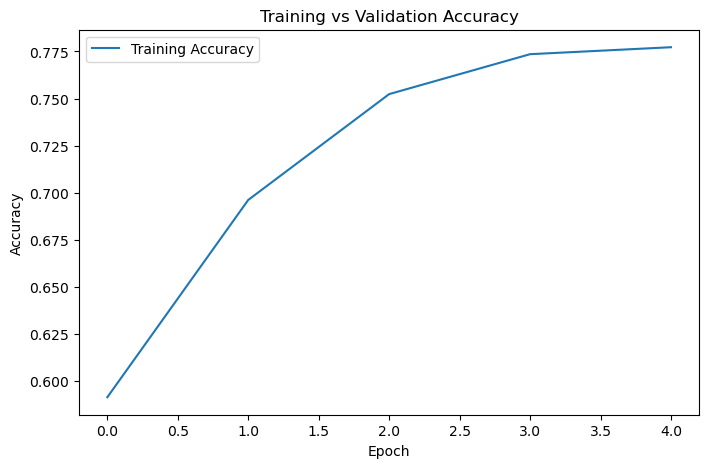

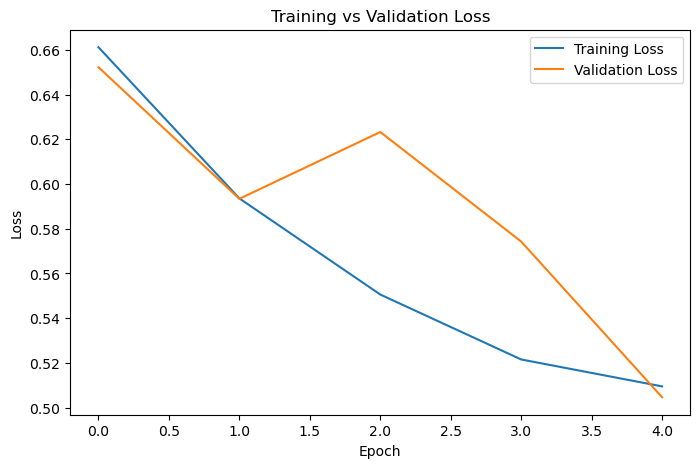

In [34]:
# PLOT ACCURACY AND LOSS
#ACCURACY PLOT
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# LOSS PLOT
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'],label="Training Loss")
plt.plot(history.history['val_loss'],label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# PREDICT ON NEW NEWS ARTICLE

In [36]:
# Test on new input
def predict_news(news_text):
    news_text=clean_text(news_text)
    seq=tokenizer.texts_to_sequences([news_text])
    padded=pad_sequences(seq,maxlen=max_len,padding="post",truncating="post")

    prediction=model.predict(padded)[0][0]

    if prediction>0.5:
        print(f"Prediction: REAL (score ={prediction:.4f})")
    else:
        print(f"Prediction: FAKE (score={prediction:.4f})")
sample_news="The government has officially announced a new policy after parliment discussion"
predict_news(sample_news)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
Prediction: FAKE (score=0.3185)
